# Machine Learning Models

## Baseline Linear Regression

Objective

Train a baseline regression model for Remaining Useful Life prediction.

## Load libraries and dataset

Load the prepared dataset

In [44]:
import pandas as pd
df = pd.read_csv('../data/processed/train_FD001_features.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 91 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   unit_number                        20631 non-null  int64  
 1   time_in_cycles                     20631 non-null  int64  
 2   operational_setting_1              20631 non-null  float64
 3   operational_setting_2              20631 non-null  float64
 4   operational_setting_3              20631 non-null  float64
 5   sensor_measurement_1               20631 non-null  float64
 6   sensor_measurement_2               20631 non-null  float64
 7   sensor_measurement_3               20631 non-null  float64
 8   sensor_measurement_4               20631 non-null  float64
 9   sensor_measurement_5               20631 non-null  float64
 10  sensor_measurement_6               20631 non-null  float64
 11  sensor_measurement_7               20631 non-null  float64
 12  s

In [45]:
import os
os.makedirs("../reports/figures", exist_ok=True)

# Recreate X and y

The target is RUL, everything else other than identifiers like `unit_number` becomes our features.

## Split the data

In [46]:
from sklearn.model_selection import GroupShuffleSplit

# 0. Drop warm up rows and leaky columns
df_model = df[df['time_in_cycles'] >= 5].reset_index(drop=True)

groups = df_model['unit_number']
x = df_model.drop(columns=['RUL', 'max_cycles', 'unit_number'])

# Cap RUL at 125 cycles.
RUL_CAP = 125
y = df_model['RUL'].clip(upper=RUL_CAP)

# 1. Split by engine; 80 engines train, 20 engines test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(x, y, groups=groups))

x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(x_train.shape, x_test.shape)
print("train engines:", groups.iloc[train_idx].nunique(),
      "test engines:", groups.iloc[test_idx].nunique())
print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))


(16241, 88) (3990, 88)
train engines: 80 test engines: 20
overlap: set()


## Import linear regression

Initialize and fit the model

In [47]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](88,)","[ -0.14,-99.47,458.81,..., 0. , -3.63, -6.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](88,)","['time_in_cycles','operational_setting_1','operational_setting_2',..., 'sensor_measurement_19_change','sensor_measurement_20_change', 'sensor_measurement_21_change']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.284e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,88
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(63)


## Predict values for unseen test data

In [48]:
lr_predictions = model.predict(x_test)

## Evaluate linear regression model

Using three metrics:
- Mean absolute error
- Root mean squared error
- R² Score

In [49]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

model_results = []

def evaluate(name, y_true, y_hat):
    """Score a model, record the result, and print it."""
    scores = {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_hat),
        "RMSE": root_mean_squared_error(y_true, y_hat),
        "R2": r2_score(y_true, y_hat),
    }

    # Overwrite any existing row for this model so re-running a cell updates it
    # in place instead of appending a duplicate.
    for i, row in enumerate(model_results):
        if row["Model"] == name:
            model_results[i] = scores
            break
    else:
        model_results.append(scores)

    print(name)
    print(f"MAE:  {scores['MAE']:.2f} cycles")
    print(f"RMSE: {scores['RMSE']:.2f} cycles")
    print(f"R²:   {scores['R2']:.3f}")

    return scores

In [50]:
evaluate("Linear Regression", y_test, lr_predictions)

Linear Regression
MAE:  14.17 cycles
RMSE: 17.65 cycles
R²:   0.821


{'Model': 'Linear Regression',
 'MAE': 14.166583203011365,
 'RMSE': 17.654473782058115,
 'R2': 0.8213312576860385}

# Plot actual vs predictions - Linear regression

Compare the predicted values to the actual values using scatter plots.

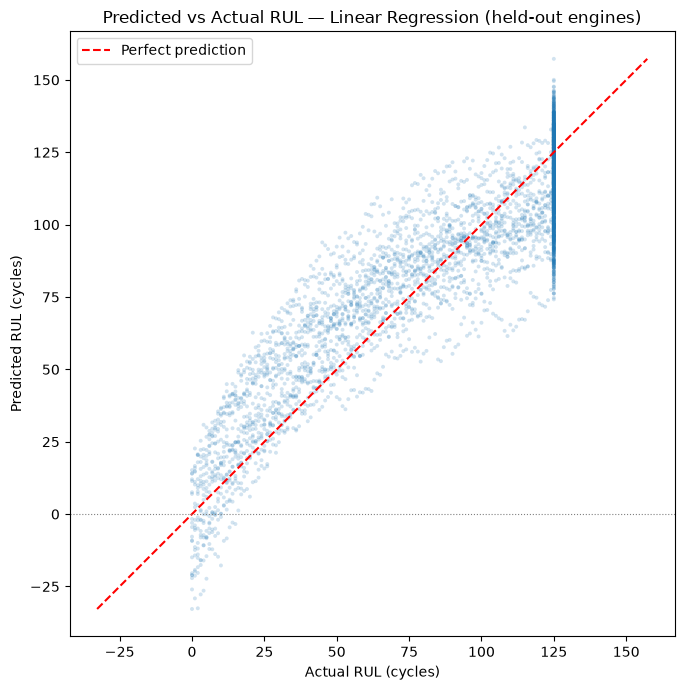

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, lr_predictions, alpha=0.2, s=8, edgecolor='none')

# Perfect prediction reference line
lims = [min(y_test.min(), lr_predictions.min()), max(y_test.max(), lr_predictions.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title('Predicted vs Actual RUL — Linear Regression (held-out engines)')
ax.set_aspect('equal')
ax.legend()

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/prediction_scatter.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Linear regression observations

- Points below the red line = the model predicts less life than the engine actually had.
- Points above the line = the model predicts more life than there was. These are the dangerous ones: the engine fails sooner than you were told.
- Predictions below zero. Linear regression is unbounded, so it will output negative RUL.


# Residual plot - Linear regression

Residuals give us a sense of the overall quality, or accuracy of the predictions made with the line.

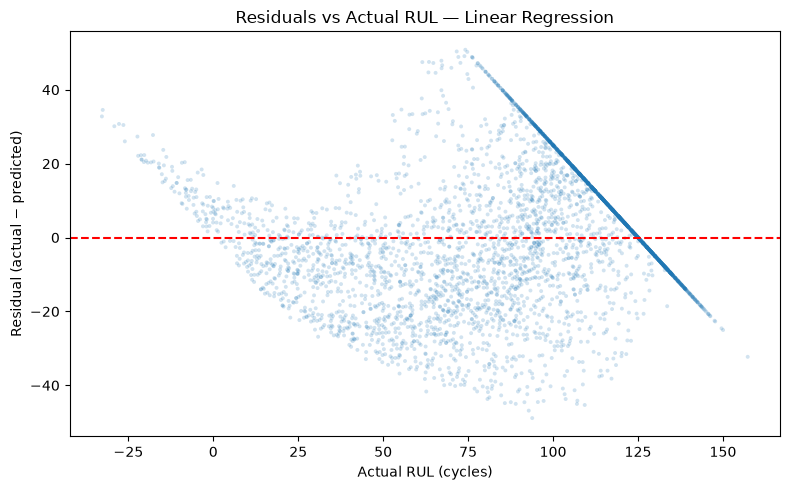

In [83]:
lr_residuals = y_test - lr_predictions

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(lr_predictions, lr_residuals, alpha=0.2, s=8, edgecolor='none')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residuals vs Actual RUL — Linear Regression')

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/linear_regressionresidual_plot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Save linear regression model

Later, the dashboard will load this file directly.

In [53]:
import joblib
joblib.dump(model, '../models/linear_regression_model.pkl')

['../models/linear_regression_model.pkl']

# Decision tree regression

The relationship between wear & tear vs health is often non linear. Decision trees can capture these non linear relationships.

In [54]:
from sklearn.tree import DecisionTreeRegressor

# An unconstrained tree grows until every leaf is pure, which memorises noise
# across 88 correlated features. Limiting depth and leaf size keeps it
# generalising; random_state makes the result reproducible.
decision_tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
)
decision_tree.fit(x_train, y_train)

# A large train/test gap here is the signature of overfitting.
print(f"train R²: {decision_tree.score(x_train, y_train):.3f}")
print(f"test R²:  {decision_tree.score(x_test, y_test):.3f}")

train R²: 0.850
test R²:  0.832


In [67]:
dt_predictions = decision_tree.predict(x_test)

In [70]:
evaluate('Decision Tree', y_test, dt_predictions)

Decision Tree
MAE:  11.63 cycles
RMSE: 17.11 cycles
R²:   0.832


{'Model': 'Decision Tree',
 'MAE': 11.634325980825817,
 'RMSE': 17.108755810224448,
 'R2': 0.8322062109408911}

# Plot actual vs predictions - Decision tree

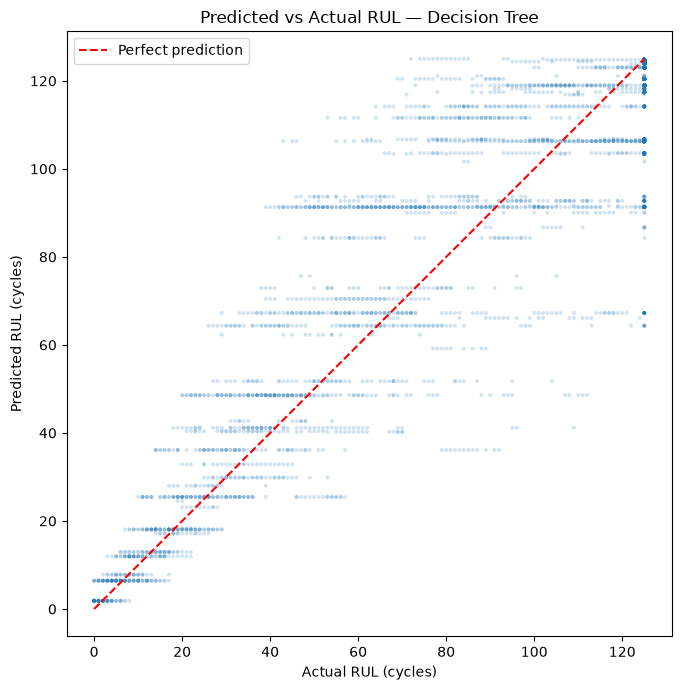

In [69]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, dt_predictions, alpha=0.2, s=8, edgecolor='none')

# Perfect prediction reference line
lims = [min(y_test.min(), dt_predictions.min()), max(y_test.max(), dt_predictions.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title('Predicted vs Actual RUL — Decision Tree')
ax.set_aspect('equal')
ax.legend()

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/decision_tree_predictions_scatter.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Residual plot - Decision tree

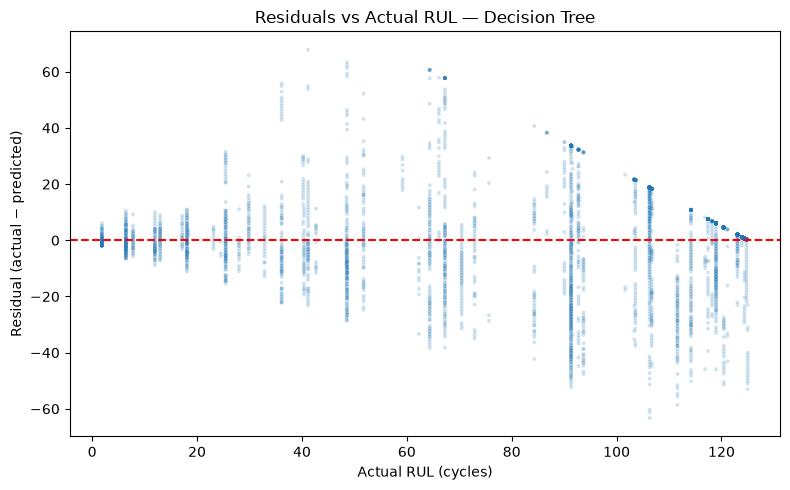

In [81]:
dt_residuals = y_test - dt_predictions

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dt_predictions, dt_residuals, alpha=0.2, s=8, edgecolor='none')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residuals vs Actual RUL — Decision Tree')

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/decision_tree_residual_plot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Decision tree observations

- Decision trees don't fit an equation. It carves the feature space into boxes with yes/no splits, and every row that lands in the same box gets the same prediction, hence the horizontal bands we see inside the plot.
- A constraint was added capping `max_depth=6` making the tree 2⁶=64 leaves, so the predictions take at most 64 distinct values across 3990 test rows.

In [73]:
joblib.dump(decision_tree, '../models/decision_tree_model.pkl')

['../models/decision_tree_model.pkl']

# Random Forest Regression

## Objective

Train a Random Forest regression model and compare its performance against the previous machine learning models.

In [60]:
from sklearn.ensemble import RandomForestRegressor

In [61]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

In [62]:
random_forest.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [63]:
rf_predictions = random_forest.predict(x_test)

In [64]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

# root_mean_squared_error already returns the root, so no ** 0.5 here.
rf_rmse = root_mean_squared_error(y_test, rf_predictions)

rf_r2 = r2_score(y_test, rf_predictions)

In [65]:
evaluate('Random forest', y_test, rf_predictions)

Random forest
MAE:  10.38 cycles
RMSE: 15.20 cycles
R²:   0.867


{'Model': 'Random forest',
 'MAE': 10.382233787487047,
 'RMSE': 15.204438951216003,
 'R2': 0.8674804891790824}

In [72]:
results_df = pd.DataFrame(model_results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,14.166583,17.654474,0.821331
1,Decision Tree,11.634326,17.108756,0.832206
2,Random forest,10.382234,15.204439,0.867480


In [80]:
joblib.dump(random_forest, '../models/random_forest_model.pkl')

['../models/random_forest_model.pkl']

# Prediction scatter plot - Random forest

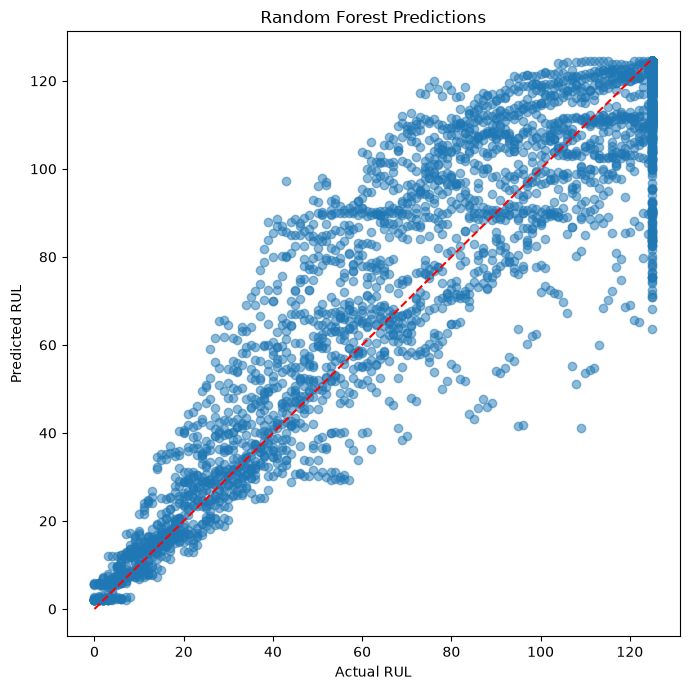

In [78]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Random Forest Predictions")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.tight_layout()
plt.savefig(
    "../reports/figures/random_forest_prediction_scatter.png",
    dpi=300
)

plt.show()

# Residual plot - Random forest

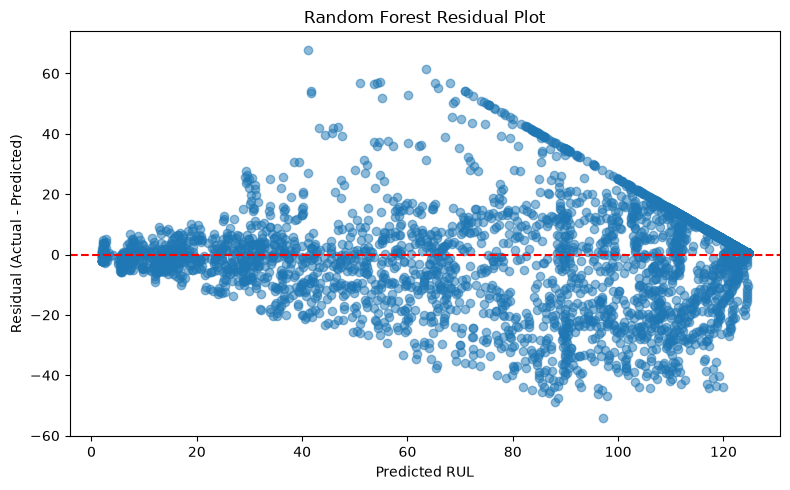

In [79]:
rf_residuals = y_test - rf_predictions

plt.figure(figsize=(8,5))

plt.scatter(
    rf_predictions,
    rf_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Random Forest Residual Plot")
plt.xlabel("Predicted RUL")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()

plt.savefig(
    "../reports/figures/random_forest_residual_plot.png",
    dpi=300
)

plt.show()

# Model Comparison Summary

In [84]:
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,14.166583,17.654474,0.821331
1,Decision Tree,11.634326,17.108756,0.832206
2,Random forest,10.382234,15.204439,0.867480


# Feature Importance Analysis

## Objective

Determine which features contribute most to predicting Remaining Useful Life using the trained Random Forest model.

In [85]:
feature_importance = random_forest.feature_importances_

In [86]:
importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": feature_importance
})

In [87]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [88]:
importance_df.head(10)

,Feature,Importance
31,sensor_measurement_4_roll_mean_5,0.676897
0,time_in_cycles,0.144623
37,sensor_measurement_11_roll_mean_5,0.082442
25,sensor_measurement_9_roll_mean_5,0.027048
41,sensor_measurement_15_roll_mean_5,0.019717
12,sensor_measurement_9,0.011403
34,sensor_measurement_7_roll_mean_5,0.010741
40,sensor_measurement_14_roll_mean_5,0.008972
29,sensor_measurement_2_roll_mean_5,0.003476
47,sensor_measurement_21_roll_mean_5,0.003348


# Importance bar chart

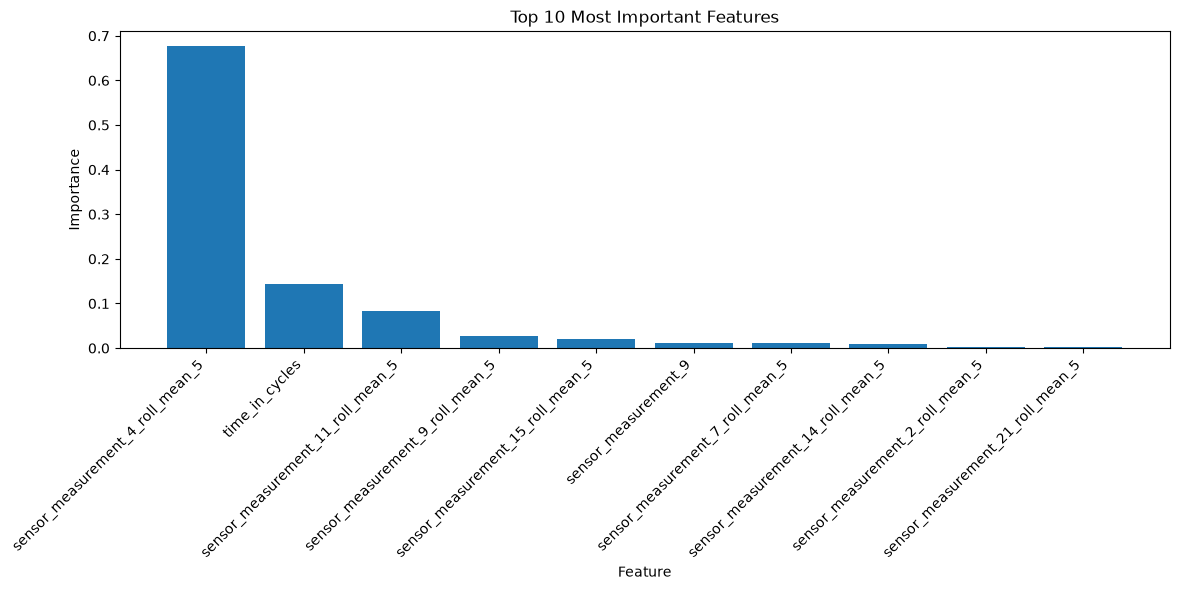

In [90]:
plt.figure(figsize=(12,6))

top_features = importance_df.head(10)

plt.bar(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Most Important Features")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_importance.png",
    dpi=300
)

plt.show()

In [92]:
# Inspect the full ranking without rerunning the notebook
importance_df.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

# Feature importance observations

- The three most important features are: sensor measurement 4 roll mean, time in cycles, sensor measurement 11 roll mean
- Time in cycles ranks high because it's a clean, unduplicated feature that encodes a genuine statistical prior, boosted by a threshold our own RUL cap created
- Drop sensors that have zero variance and near constant features, exact duplicates, and IDs
- Low importance features are usually harmless. Trees and regularized linear models largely ignore them
- For low importance: prune for a stated reason; cost, latency, interpretability, deployment simplicity. Not because a chart ranked it last, and decide with cross vlidation not a single holdout, so that we're not fitting the feature set to one arbitrary split
